<a href="https://colab.research.google.com/github/jyothirmaij/supervised_casestudy_jyothirmai/blob/main/supervised_learnig_casestudy_jyothirmai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import VarianceThreshold

In [6]:
cancer = load_breast_cancer()
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [7]:
df = pd.DataFrame(cancer.data,columns=cancer.feature_names)
df['target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [9]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [10]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [11]:
df.duplicated().sum()

np.int64(0)

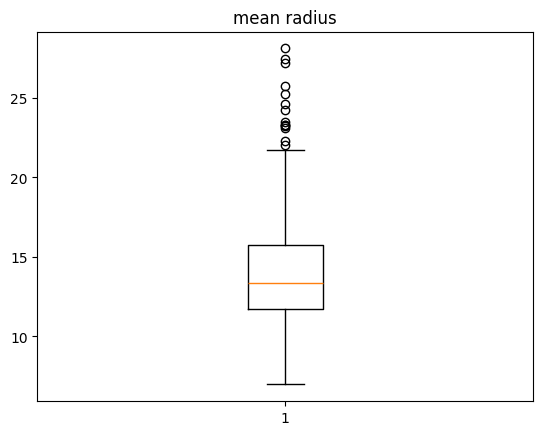

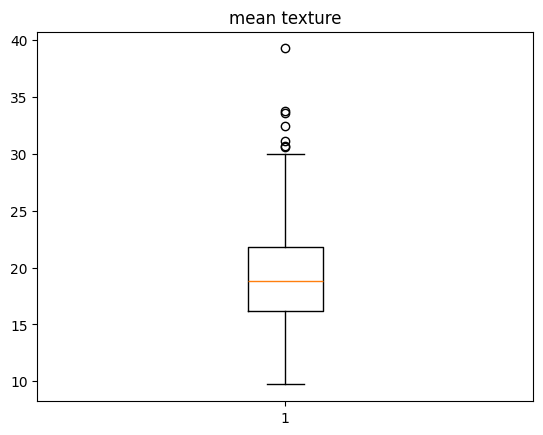

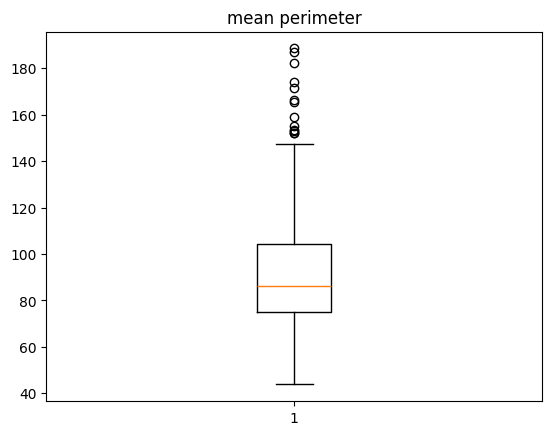

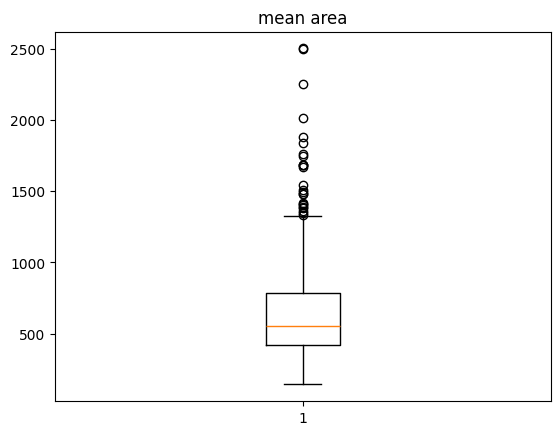

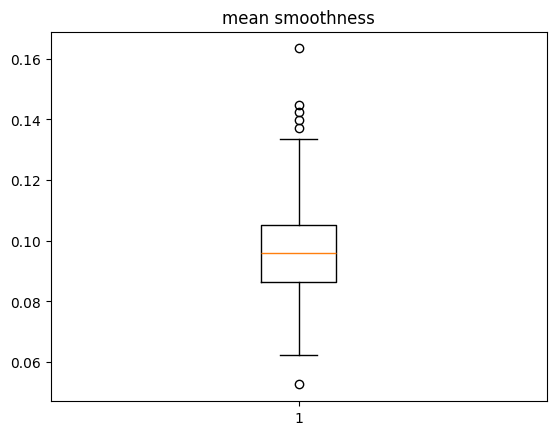

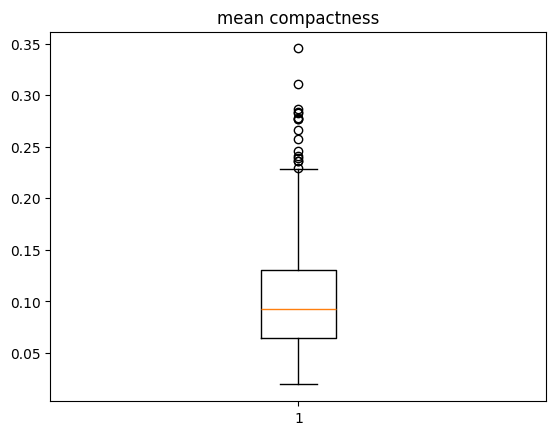

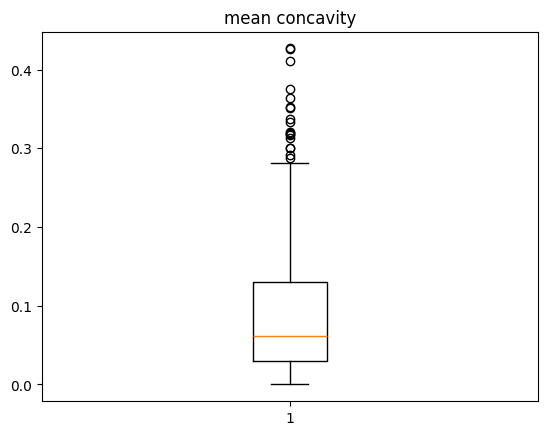

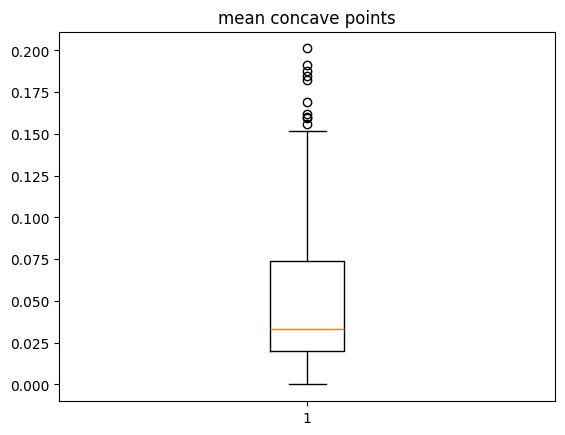

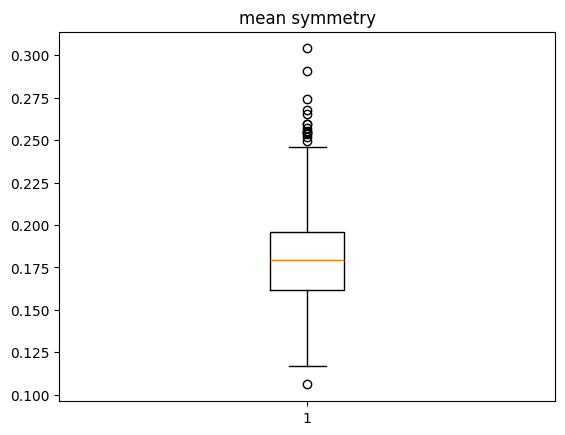

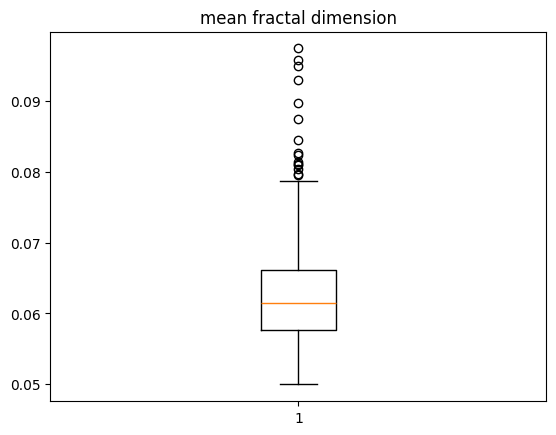

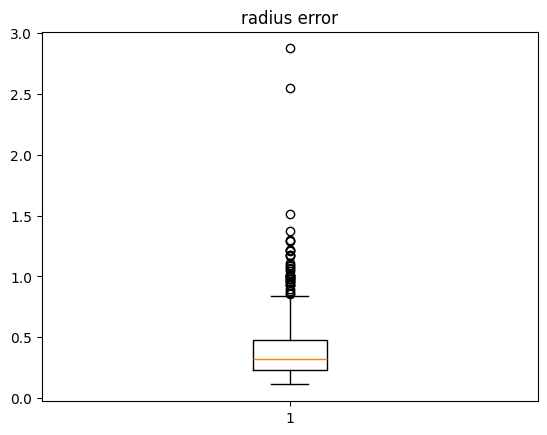

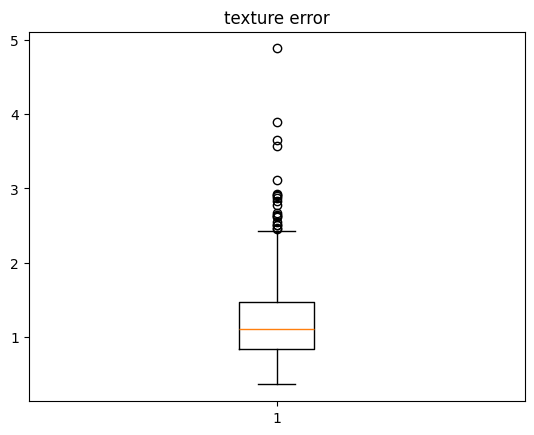

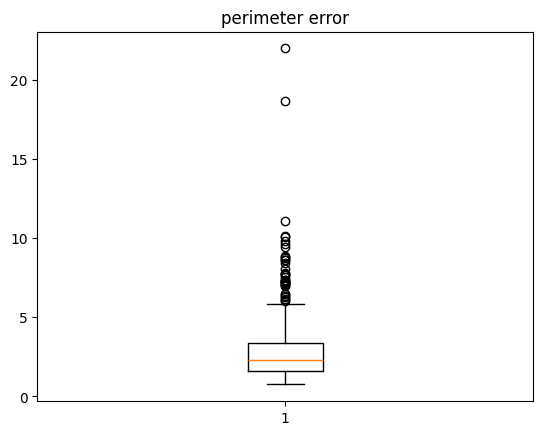

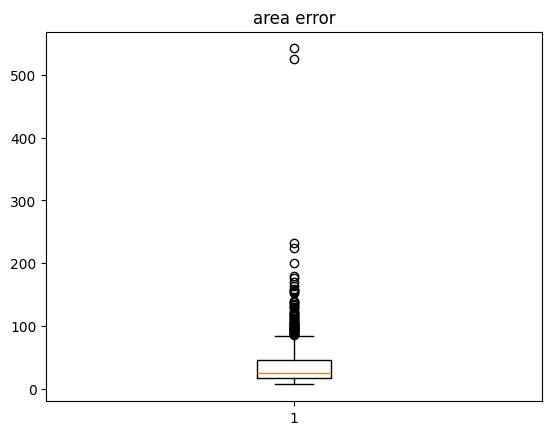

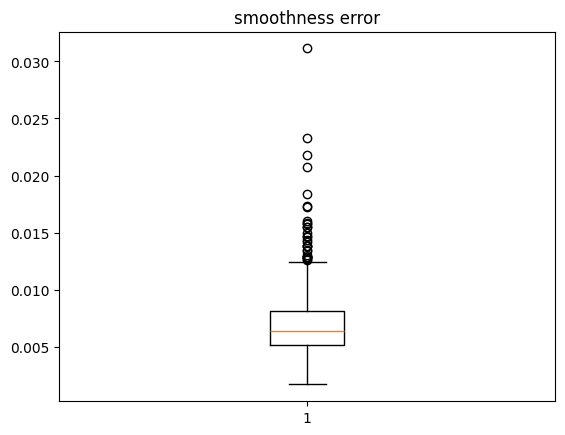

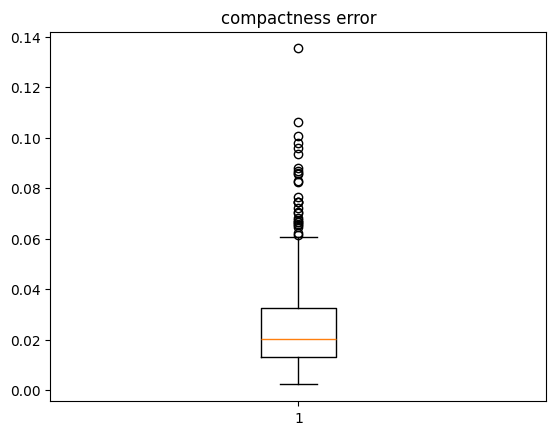

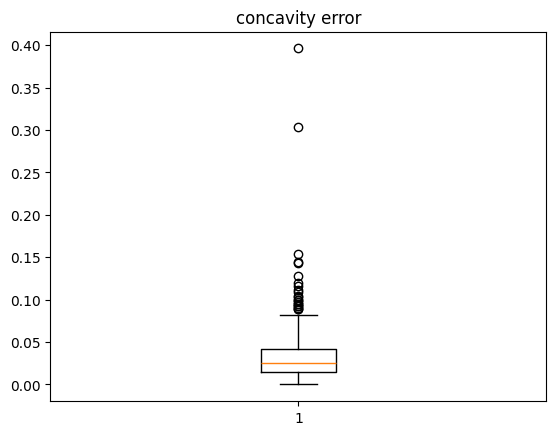

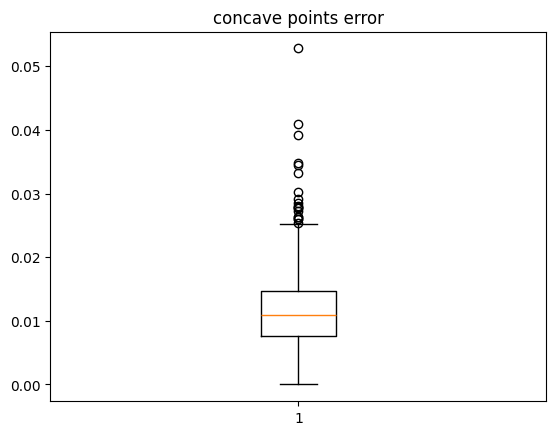

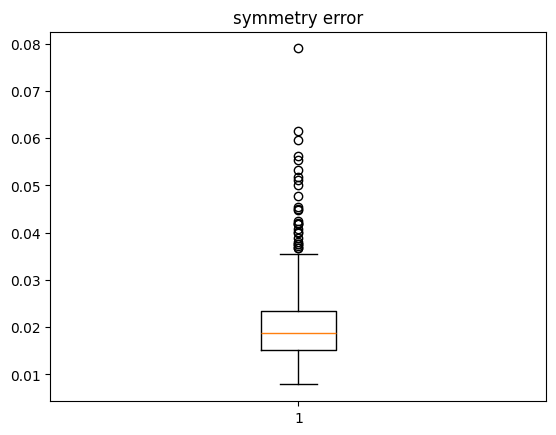

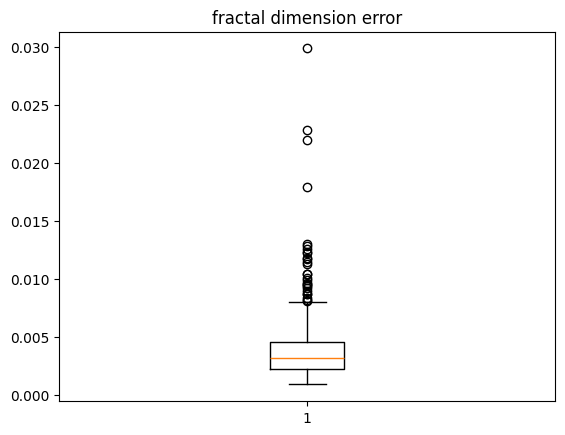

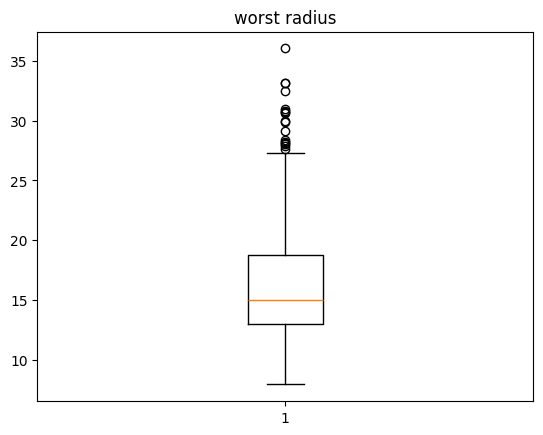

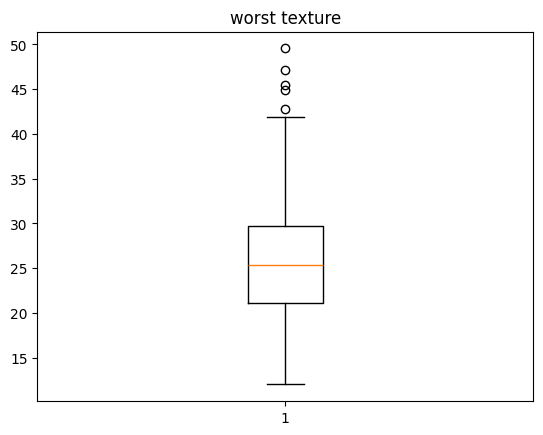

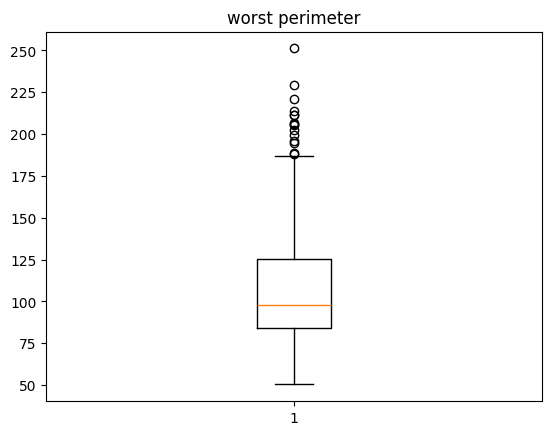

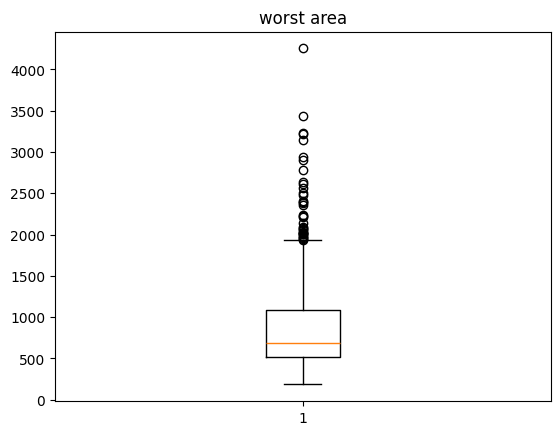

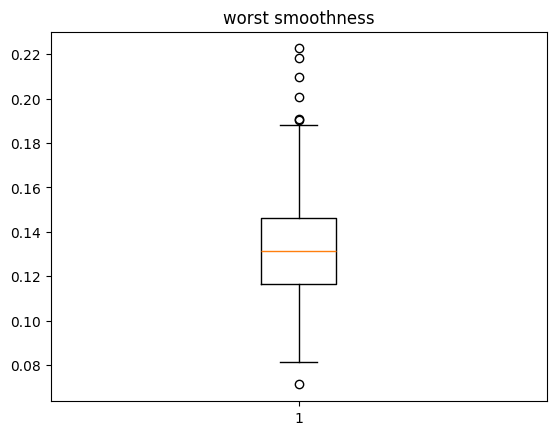

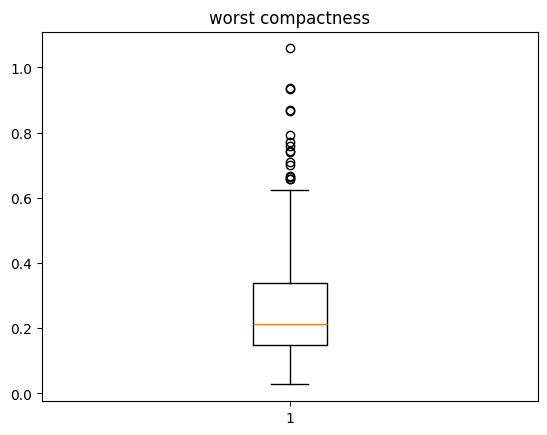

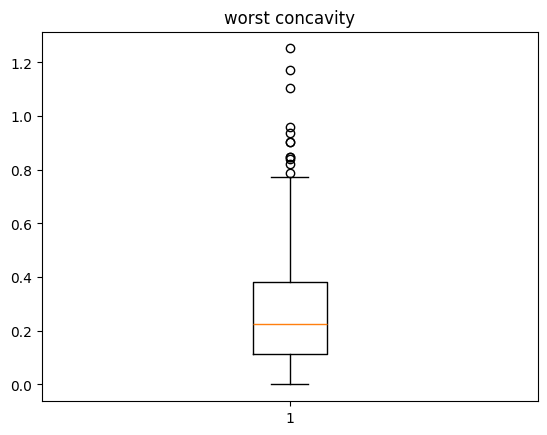

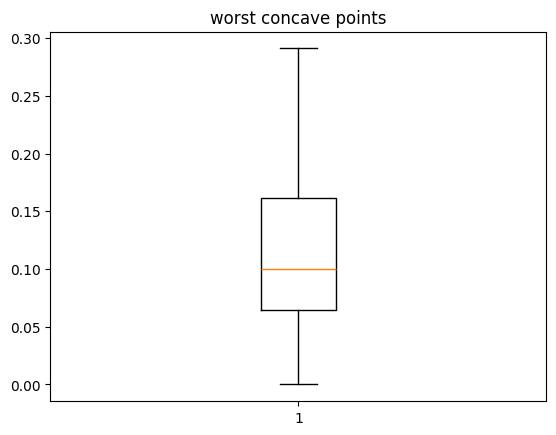

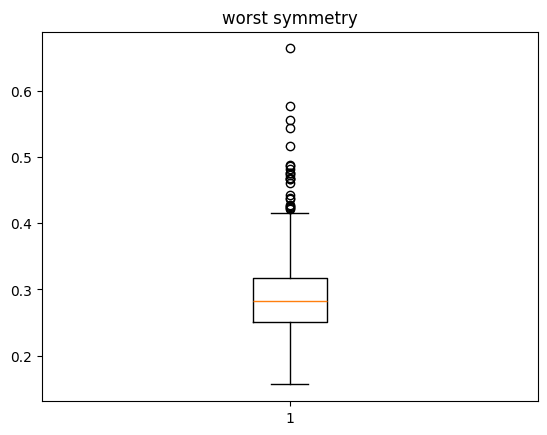

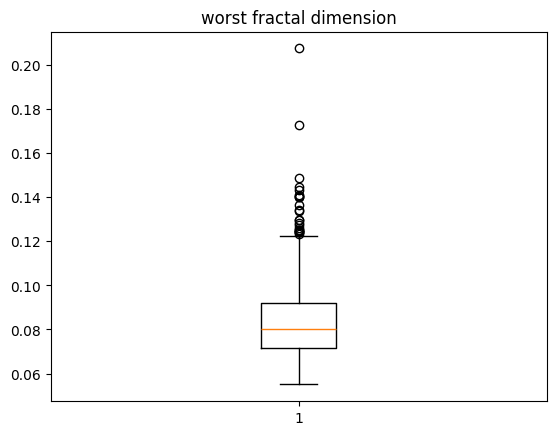

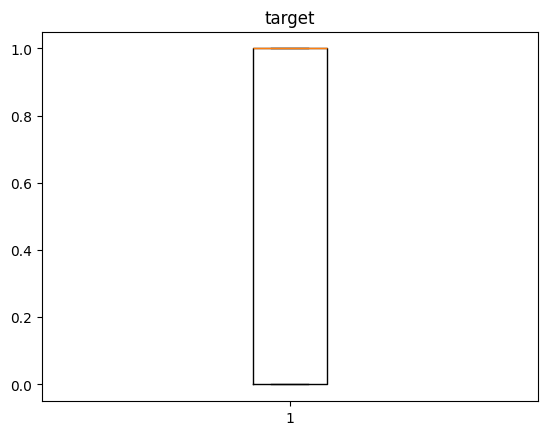

In [12]:
columns = df.select_dtypes(include=['number']).columns
for i in columns:
  plt.boxplot(df[i])
  plt.title(i)
  plt.show()

In [13]:
# to split the data in to train and test
x = df.drop('target',axis=1)
y = df['target']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)
pd.Series(y_train).value_counts()

(455, 30) (114, 30) (455,) (114,)


,count
target,
1,286
0,169


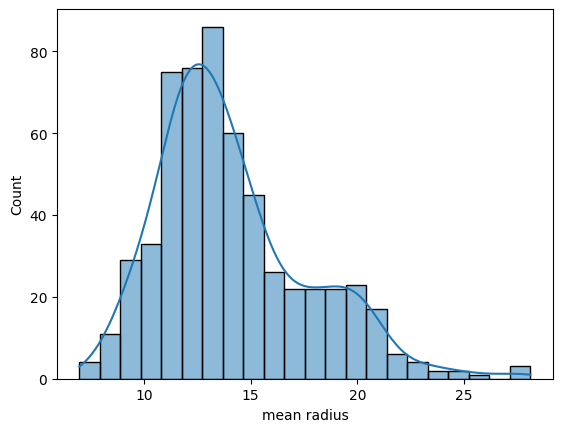

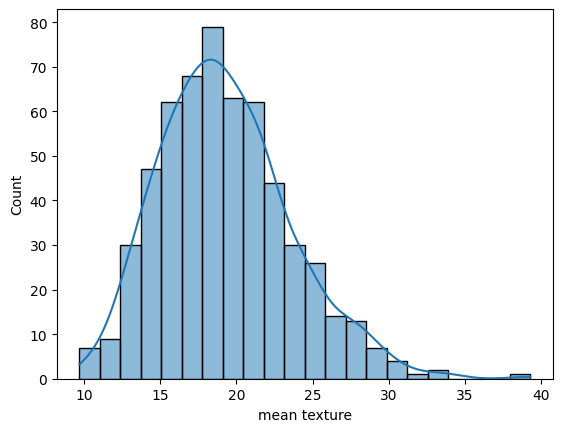

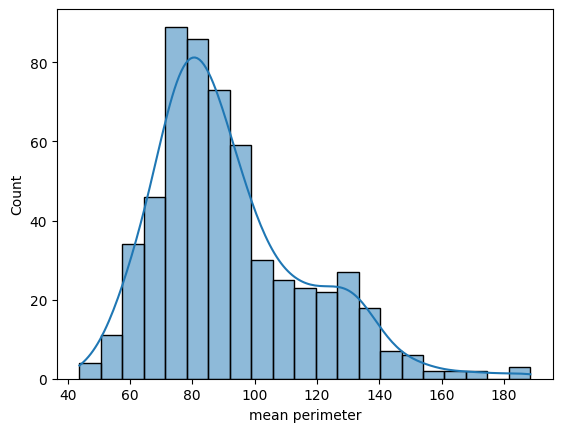

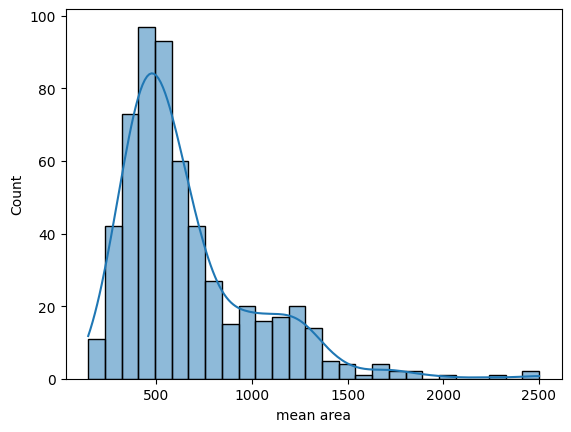

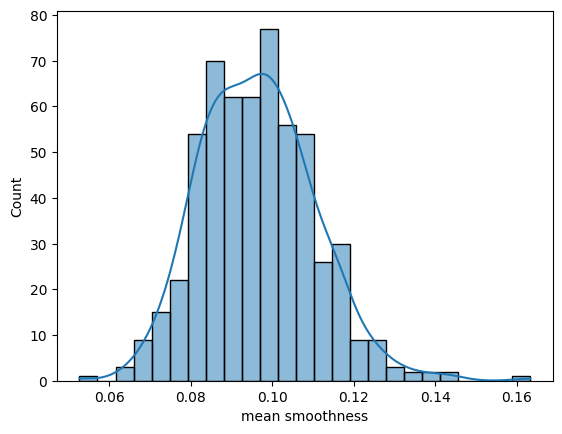

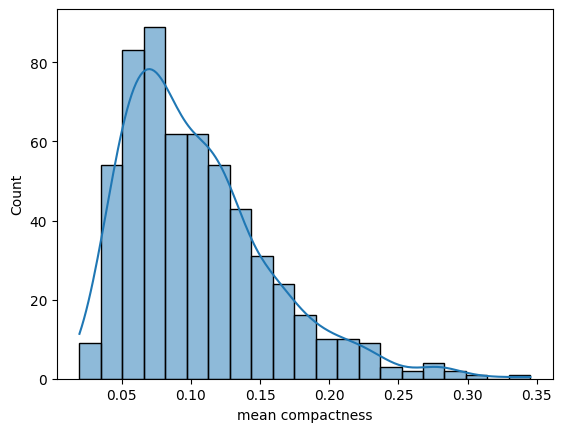

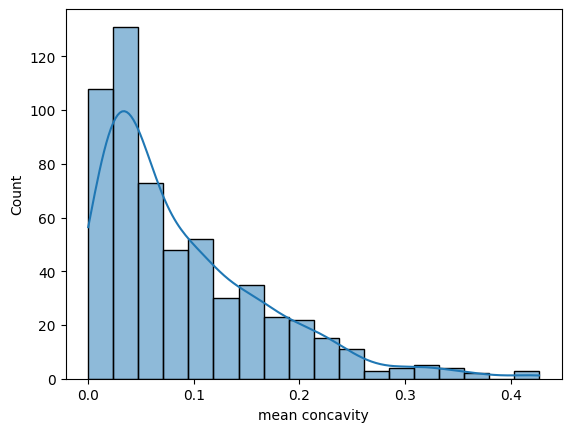

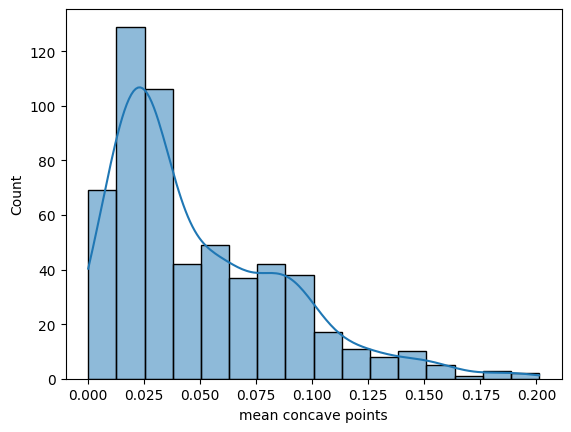

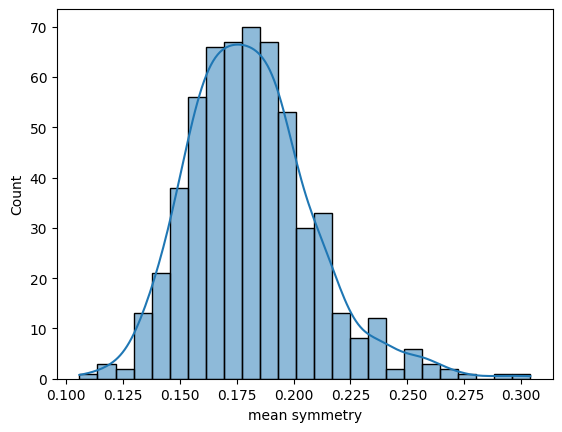

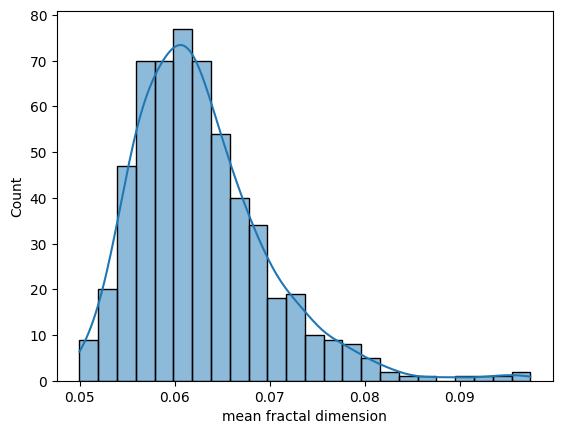

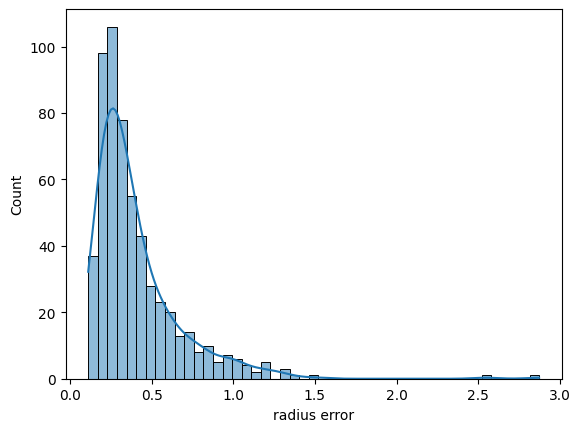

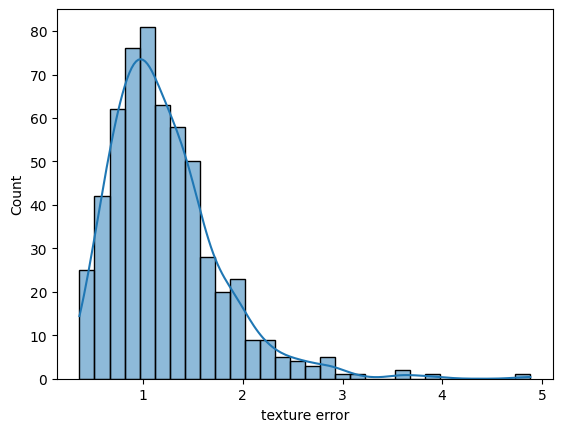

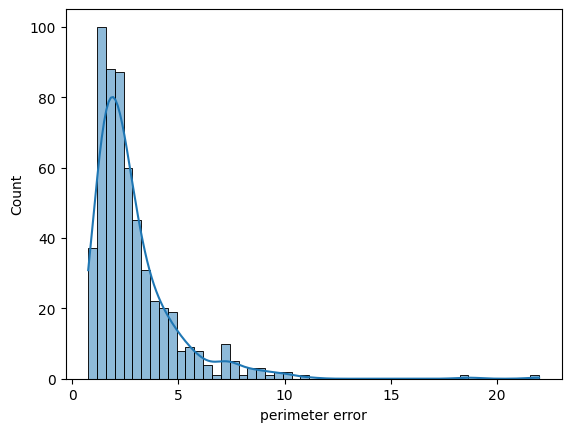

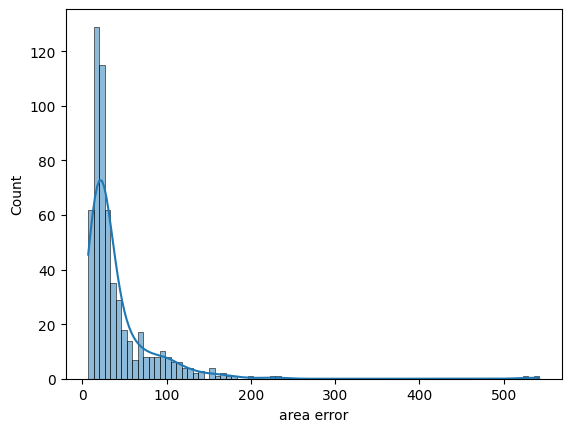

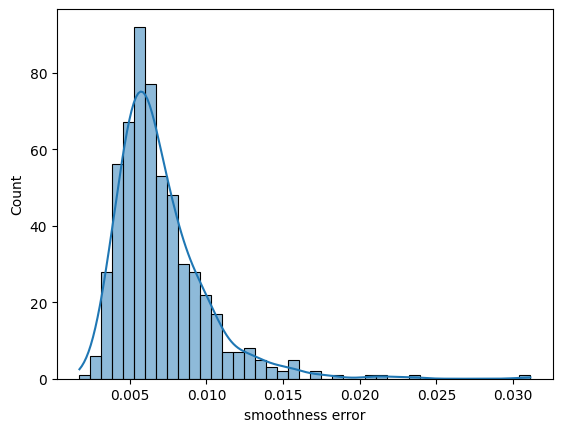

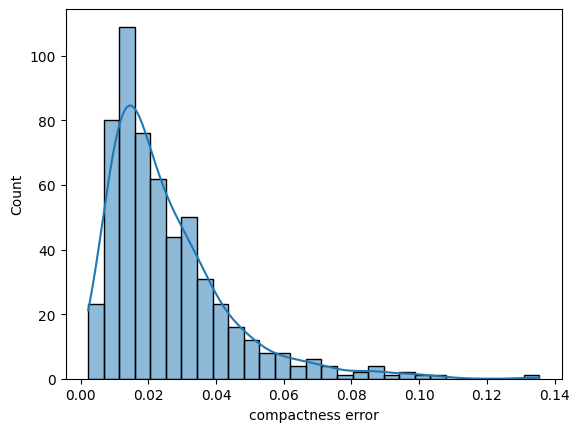

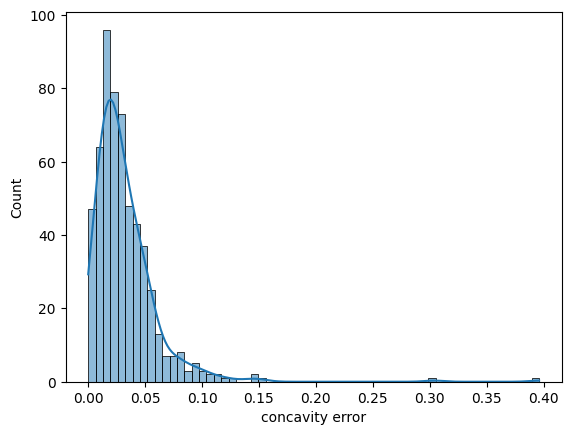

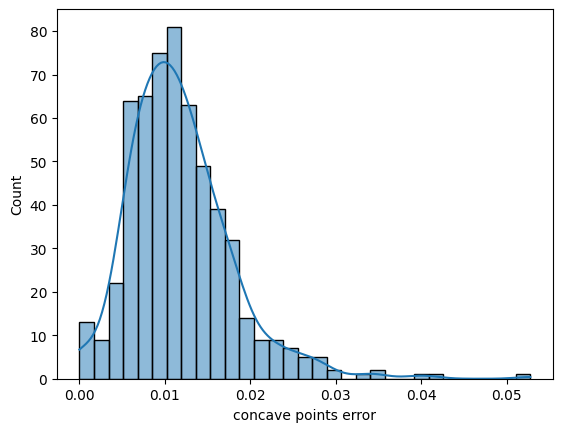

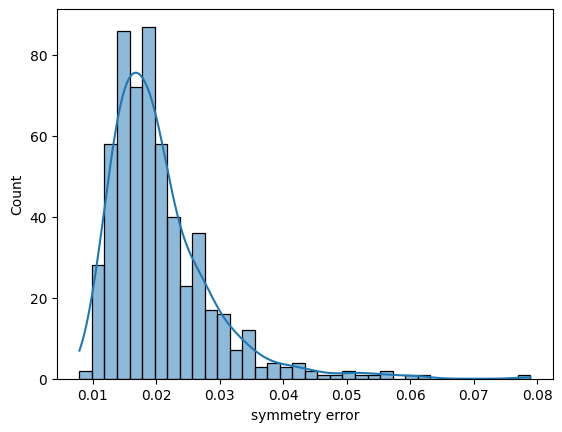

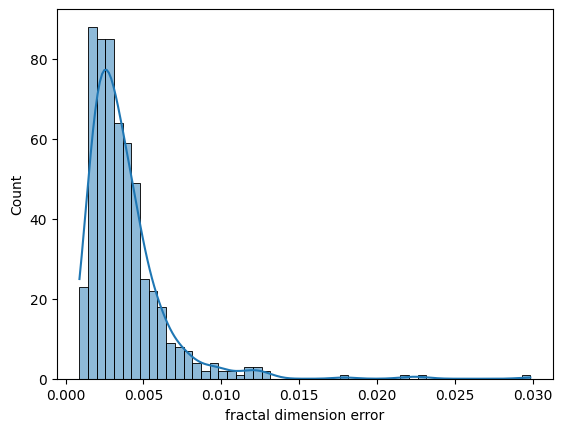

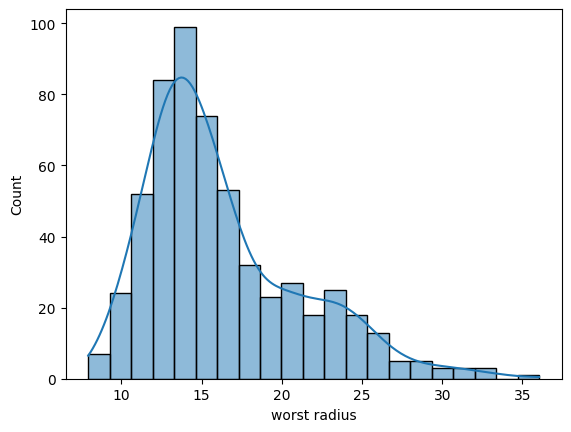

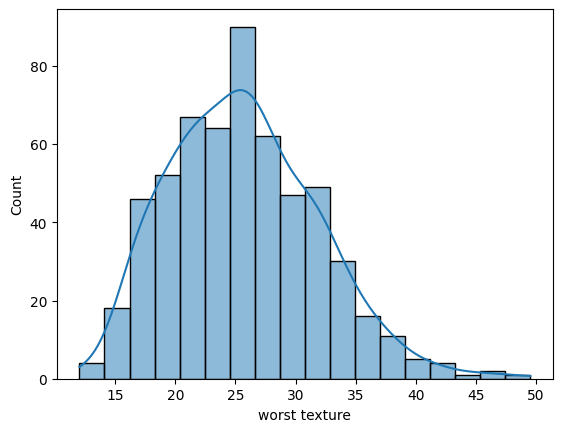

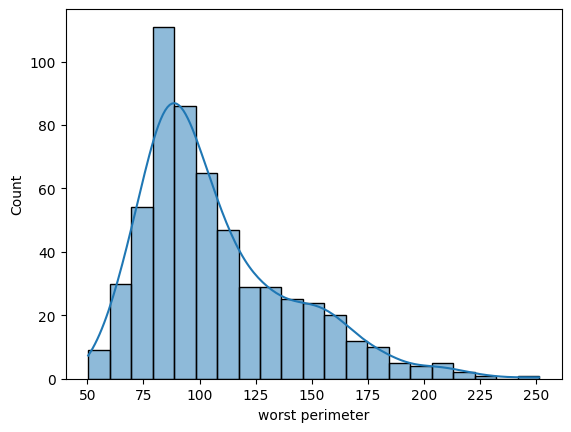

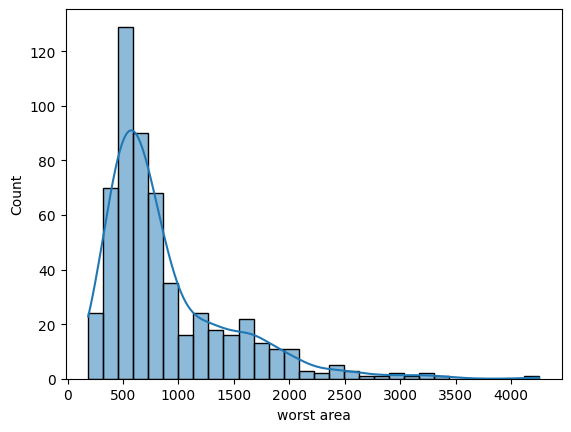

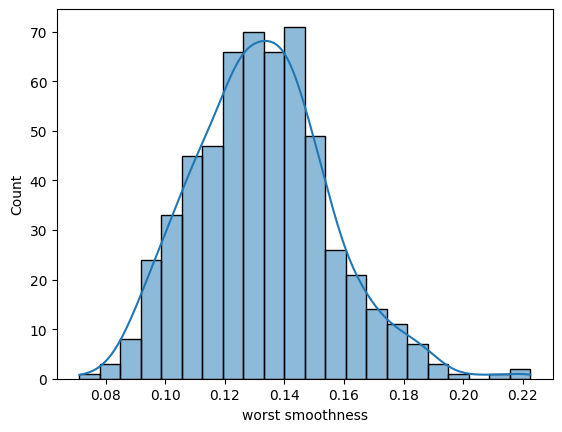

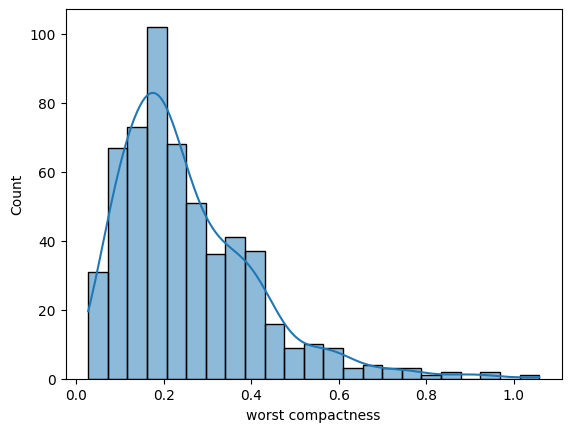

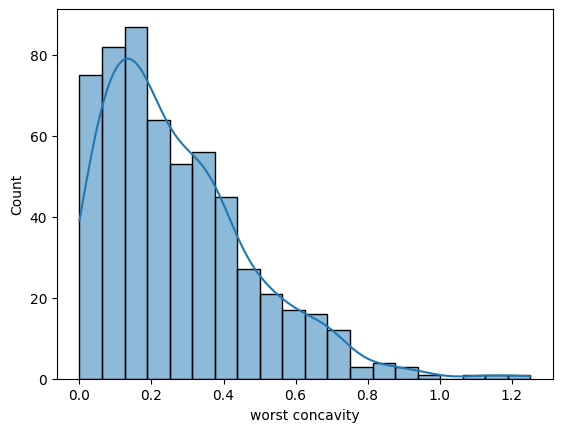

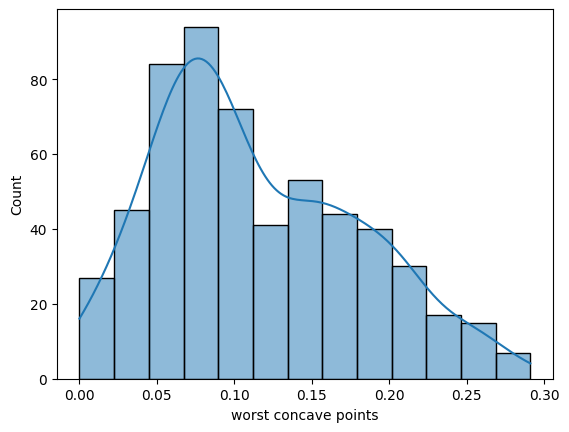

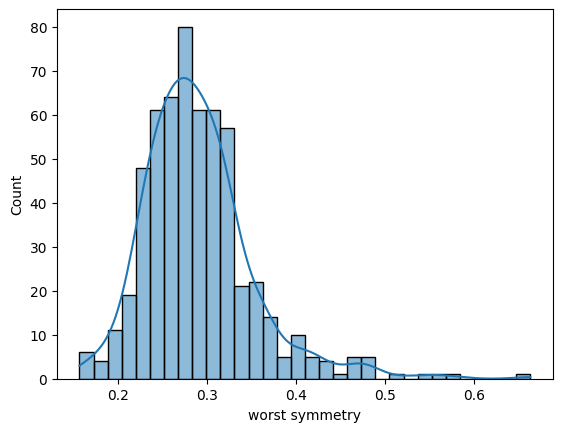

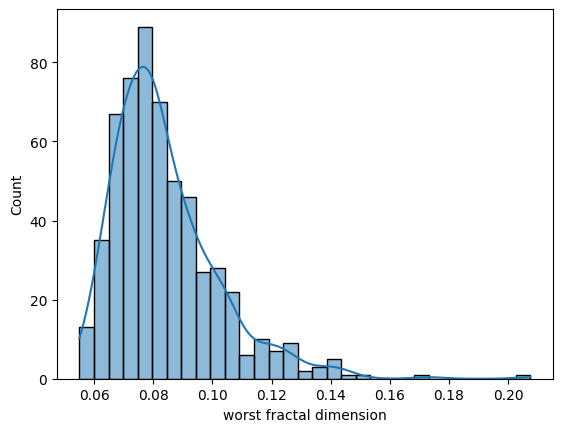

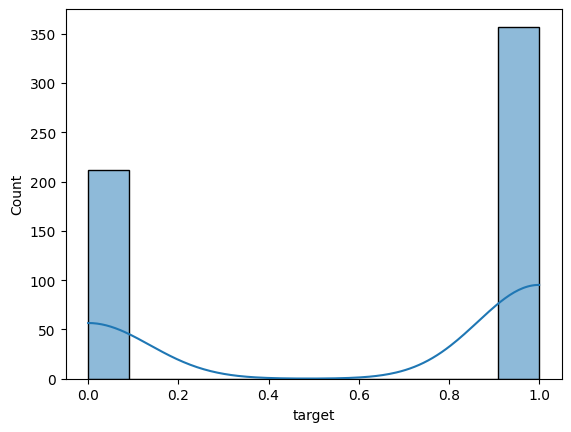

In [14]:
# to create the histplot of all the columns with kde = True
for i in df.columns:
  sns.histplot(df[i],kde=True)
  plt.show()


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [16]:
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9824561403508771
[[41  2]
 [ 0 71]]


KNN

In [17]:
from sklearn.neighbors import KNeighborsClassifier

metric_k=[]
neighbors = np.arange(3,20)

for i in neighbors:
  knn_model = KNeighborsClassifier(n_neighbors=i)
  knn_model.fit(x_train,y_train)
  y_pred_knn = knn_model.predict(x_test)
  metric_k.append(accuracy_score(y_test,y_pred_knn))

metric_k

[0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9473684210526315,
 0.956140350877193,
 0.9649122807017544,
 0.956140350877193,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.956140350877193,
 0.956140350877193]

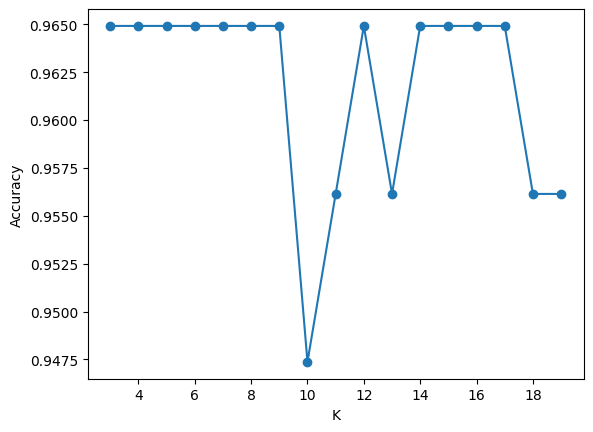

In [18]:
plt.plot(neighbors,metric_k,marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [19]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(x_train,y_train)
y_pred_knn = knn_classifier.predict(x_test)
print(accuracy_score(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.9649122807017544
[[41  2]
 [ 2 69]]


**NAIVE BAYES CLASSSIFICATION**

In [20]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train,y_train)
y_pred_nb = nb_model.predict(x_test)

print(accuracy_score(y_test,y_pred_nb))
print(confusion_matrix(y_test,y_pred_nb))

0.9649122807017544
[[40  3]
 [ 1 70]]


DECISION TREE

In [21]:
from sklearn.tree import DecisionTreeClassifier
dec_tree = DecisionTreeClassifier(random_state = 12)
dec_tree.fit(x_train,y_train)
y_pred_dt = dec_tree.predict(x_test)

print(accuracy_score(y_test,y_pred_dt))
print(confusion_matrix(y_test,y_pred_dt))

0.9385964912280702
[[40  3]
 [ 4 67]]


In [22]:
from sklearn.tree import DecisionTreeClassifier
dec_tree=DecisionTreeClassifier(random_state = 30,
                                min_samples_split = 10,
                                min_samples_leaf = 5,
                                max_depth = 5)
dec_tree.fit(x_train,y_train)
y_pred_dt=dec_tree.predict(x_test)

print(accuracy_score(y_test,y_pred_dt))
print(confusion_matrix(y_test,y_pred_dt))

0.9473684210526315
[[39  4]
 [ 2 69]]


RANDOM FOREST ALGORITHM

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.9649122807017544
[[40  3]
 [ 1 70]]


In [24]:
rf_model = RandomForestClassifier(random_state=42, n_estimators = 200,n_jobs = -1,class_weight = 'balanced',max_depth = 10,min_samples_split = 5)
rf_model.fit(x_train,y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.9736842105263158
[[41  2]
 [ 1 70]]


FEATURE REDUCTION

In [25]:
from sklearn.feature_selection import VarianceThreshold

In [26]:
feature_variances = df.var()
display(feature_variances)

,0
mean radius,12.418920
mean texture,18.498909
mean perimeter,590.440480
mean area,123843.554318
mean smoothness,0.000198
mean compactness,0.002789
mean concavity,0.006355
mean concave points,0.001506
mean symmetry,0.000752
mean fractal dimension,0.000050


In [27]:
selector = VarianceThreshold(threshold = 0.5)
reduced = selector.fit_transform(df.drop(columns=['target']))
reduced.shape

(569, 10)

In [28]:
selector.get_feature_names_out()

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'perimeter error', 'area error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area'], dtype=object)

RECURSIVE FEATURE ELIMINATION

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
estimator = RandomForestClassifier(random_state = 42,n_estimators = 100)

selector = RFE(estimator,n_features_to_select = 10, step = 1)
x=df.drop(columns=['target'])
y=df['target']
selector.fit(x,y)

RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=10)

In [30]:
selector.get_feature_names_out()

array(['mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst concavity',
       'worst concave points'], dtype=object)

In [31]:
selector.estimator_.feature_importances_

array([0.03523969, 0.05002391, 0.0273354 , 0.13212671, 0.12163132,
       0.03749994, 0.239965  , 0.14059681, 0.02824236, 0.18733888])

In [32]:
# check the feature importance of the model
estimator.fit(x,y)
estimator.feature_importances_

array([0.03484323, 0.01522515, 0.06799034, 0.06046164, 0.00795845,
       0.01159704, 0.06691736, 0.10704566, 0.00342279, 0.00261508,
       0.0142637 , 0.00374427, 0.01008506, 0.02955283, 0.00472157,
       0.00561183, 0.00581969, 0.00375975, 0.00354597, 0.00594233,
       0.08284828, 0.01748526, 0.0808497 , 0.13935694, 0.01223202,
       0.01986386, 0.03733871, 0.13222509, 0.00817908, 0.00449731])

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'mean radius'),
  Text(1, 0, 'mean texture'),
  Text(2, 0, 'mean perimeter'),
  Text(3, 0, 'mean area'),
  Text(4, 0, 'mean smoothness'),
  Text(5, 0, 'mean compactness'),
  Text(6, 0, 'mean concavity'),
  Text(7, 0, 'mean concave points'),
  Text(8, 0, 'mean symmetry'),
  Text(9, 0, 'mean fractal dimension'),
  Text(10, 0, 'radius error'),
  Text(11, 0, 'texture error'),
  Text(12, 0, 'perimeter error'),
  Text(13, 0, 'area error'),
  Text(14, 0, 'smoothness error'),
  Text(15, 0, 'compactness error'),
  Text(16, 0, 'concavity error'),
  Text(17, 0, 'concave points error'),
  Text(18, 0, 'symmetry error'),
  Text(19, 0, 'fractal dimension error'),
  Text(20, 0, 'worst radius'),
  Text(21, 0, 'worst texture'),
  Text(22, 0, 'worst perimeter'),
  Text(23, 0, 'worst area'),
  Text(24, 0, 'worst smoothness')

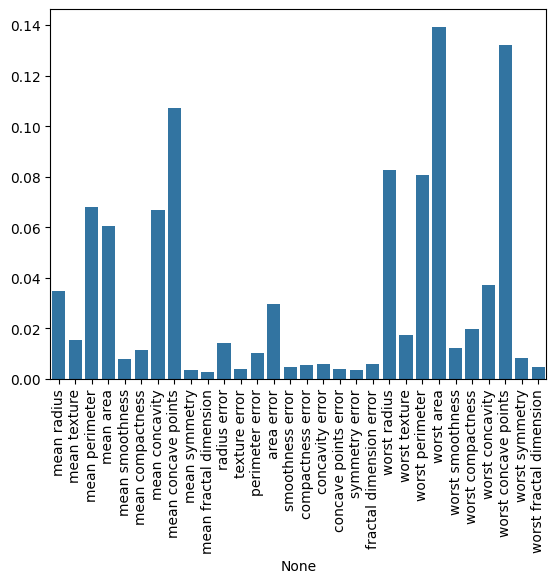

In [33]:
import matplotlib.pyplot as plt
sns.barplot(x=x.columns,y=estimator.feature_importances_)
plt.xticks(rotation=90)

**SelectKBest**

In [34]:
from sklearn.feature_selection import SelectKBest,f_classif

selector_kbest = SelectKBest(score_func=f_classif,k=8)
selector_kbest.fit(x,y)

SelectKBest(k=8)

In [35]:
selector_kbest.transform(x)
selector_kbest.get_feature_names_out()

array(['mean radius', 'mean perimeter', 'mean area',
       'mean concave points', 'worst radius', 'worst perimeter',
       'worst area', 'worst concave points'], dtype=object)

In [36]:
selector_kbest.scores_

array([6.46981021e+02, 1.18096059e+02, 6.97235272e+02, 5.73060747e+02,
       8.36511234e+01, 3.13233079e+02, 5.33793126e+02, 8.61676020e+02,
       6.95274435e+01, 9.34592949e-02, 2.68840327e+02, 3.90947023e-02,
       2.53897392e+02, 2.43651586e+02, 2.55796780e+00, 5.32473391e+01,
       3.90144816e+01, 1.13262760e+02, 2.41174067e-02, 3.46827476e+00,
       8.60781707e+02, 1.49596905e+02, 8.97944219e+02, 6.61600206e+02,
       1.22472880e+02, 3.04341063e+02, 4.36691939e+02, 9.64385393e+02,
       1.18860232e+02, 6.64439606e+01])

In [37]:
pd.Series(selector_kbest.scores_,index = x.columns)

,0
mean radius,646.981021
mean texture,118.096059
mean perimeter,697.235272
mean area,573.060747
mean smoothness,83.651123
mean compactness,313.233079
mean concavity,533.793126
mean concave points,861.676020
mean symmetry,69.527444
mean fractal dimension,0.093459


In [38]:
pd.Series(selector_kbest.scores_,index = x.columns)

,0
mean radius,646.981021
mean texture,118.096059
mean perimeter,697.235272
mean area,573.060747
mean smoothness,83.651123
mean compactness,313.233079
mean concavity,533.793126
mean concave points,861.676020
mean symmetry,69.527444
mean fractal dimension,0.093459


In [39]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scler=StandardScaler()
x_train=scler.fit_transform(x_train)
x_test=scler.transform(x_test)

In [40]:
pca_applied = PCA(n_components=9)
pca_applied.fit(x_train)
x_train_pca = pca_applied.fit_transform(x_train)
x_test_pca = pca_applied.transform(x_test)

In [41]:
explained_variance = pca_applied.explained_variance_ratio_
explained_variance

array([0.43502782, 0.19500007, 0.09781519, 0.06486409, 0.05253378,
       0.041128  , 0.0223559 , 0.01647952, 0.01380052])

In [42]:
sum(explained_variance)

np.float64(0.9390048843469665)

In [43]:
df_train_pca = pd.DataFrame(x_train_pca, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8','PC9'])
df_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,4.244903,9.131428,1.504262,-0.650982,-4.321306,1.684281,-1.999392,0.328794,-3.733334
1,9.053755,0.475310,-3.198215,0.704403,-0.324461,0.648746,0.848774,-0.243660,1.070485
2,-2.275374,3.278471,2.816370,-0.268242,0.582721,2.988050,0.138743,-0.489081,0.498985
3,-2.510453,0.743743,-0.736034,2.524633,1.639580,0.088052,0.170851,0.258152,-0.578347
4,-2.302848,2.665155,1.192885,-1.268602,3.516421,2.795426,0.538828,-0.752522,-0.132848


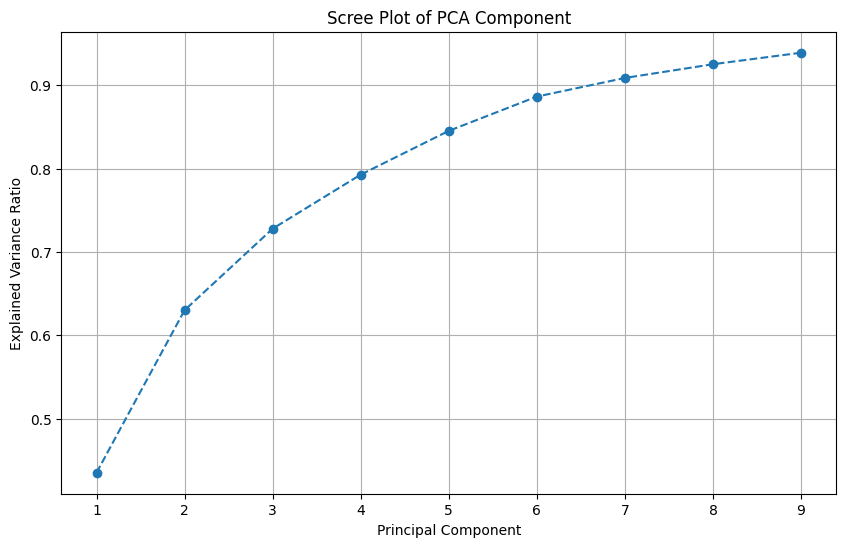

In [44]:
plt.figure(figsize=(10,6))
plt.plot(range(1,len(pca_applied.explained_variance_ratio_)+1),pca_applied.explained_variance_ratio_.cumsum(),marker='o',linestyle='--')
plt.title('Scree Plot of PCA Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()